# Business Cost Tracker Dashboard — Capstone / Hackathon Submission

A full-stack web app for logging, categorizing, and visualizing business expenses:
a Node.js/Express REST API with JWT auth and a SQLite database, plus a single-page
dashboard frontend (Chart.js) showing spend trends, category breakdowns, and
budget-vs-actual tracking.

This notebook is organized in three parts:

1. **Project overview** — problem, approach, architecture
2. **Executable analysis** — regenerates the synthetic expense dataset and reproduces
   the dashboard's core analytics and charts using Python (pandas / matplotlib), so the
   data story can be explored directly in this notebook
3. **Full source code** — the complete backend and frontend implementation, included
   as reference (this notebook's kernel is Python, so the Node.js/JavaScript/HTML
   files are shown as documented code blocks rather than executed here — the app
   itself runs locally with `npm install && npm run seed && npm start`, see the
   final section)


## 1. Project Overview

**Problem:** Small businesses and teams often track expenses across scattered
spreadsheets with no real-time visibility into category spend versus budget.
Enterprise tools (QuickBooks, SAP) solve this but are expensive and heavyweight
for a small team's needs.

**Solution:** A lightweight, self-hosted cost tracker: expense CRUD, category
budgets, and a dashboard that visualizes total spend, monthly trends, category
breakdowns, budget-vs-actual status, and top vendors.

**Architecture (3-tier):**

```
Browser (SPA: HTML/JS + Chart.js)
        |  REST / JSON
        v
Express API (Node.js) -- routes: auth, expenses, categories, analytics
        |
        v
SQLite (via Node's built-in node:sqlite module)
```

**Data model:**

- `users` — id, name, email, password_hash, role
- `categories` — id, name, monthly_budget
- `expenses` — id, category_id (FK), vendor, amount, date, description, created_by (FK)

**Why a built-in SQLite module instead of a third-party driver:** avoids native
compilation entirely, so the project runs on any machine with Node 22.5+ with
zero build-toolchain requirements — important for reliable demos and grading.


## 2. Executable Analysis

The cells below regenerate the same synthetic dataset used by the live app
(513 expense records, 8 categories, ~25 vendors, 12 months of seasonally-varied
spend) and reproduce the dashboard's core analytics natively in this notebook.


In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date

random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

CATEGORIES = [
    ("Payroll", 45000),
    ("Rent & Utilities", 12000),
    ("Software & Subscriptions", 5000),
    ("Marketing", 8000),
    ("Travel", 4000),
    ("Office Supplies", 1500),
    ("Professional Services", 6000),
    ("Equipment", 5000),
]

VENDORS = {
    "Payroll": ["Gusto Payroll", "ADP"],
    "Rent & Utilities": ["Skyline Properties", "Metro Electric", "CityWater Co", "Comcast Business"],
    "Software & Subscriptions": ["AWS", "Slack", "Salesforce", "Adobe", "Zoom", "GitHub"],
    "Marketing": ["Meta Ads", "Google Ads", "Mailchimp", "LinkedIn Ads", "Canva"],
    "Travel": ["Delta Airlines", "Marriott", "Uber for Business", "United Airlines"],
    "Office Supplies": ["Staples", "Amazon Business", "Office Depot"],
    "Professional Services": ["Deloitte Consulting", "Local Law Partners", "TaxPro CPA"],
    "Equipment": ["Dell", "Apple Business", "Herman Miller"],
}

SEASONALITY = {
    "Payroll": [1.0]*11 + [1.15],
    "Rent & Utilities": [1.15, 1.1, 1.0, 0.95, 0.9, 1.05, 1.15, 1.15, 0.95, 0.9, 1.0, 1.1],
    "Software & Subscriptions": [1.0]*12,
    "Marketing": [0.8, 0.8, 0.9, 1.0, 1.0, 0.9, 0.8, 0.9, 1.1, 1.2, 1.4, 1.5],
    "Travel": [0.7, 0.8, 1.0, 1.1, 1.0, 1.1, 0.6, 0.6, 1.1, 1.2, 1.3, 0.8],
    "Office Supplies": [1.2, 0.9, 0.9, 1.0, 1.0, 0.9, 0.9, 1.1, 1.2, 1.0, 1.0, 1.1],
    "Professional Services": [1.3, 1.0, 1.4, 1.0, 0.9, 0.9, 0.9, 0.9, 1.0, 1.0, 1.0, 1.2],
    "Equipment": [1.1, 0.8, 0.8, 0.9, 0.8, 0.8, 0.8, 1.0, 1.0, 0.9, 0.9, 1.3],
}

START = date(2025, 7, 1)
MONTHS = 12

def month_range(start, n):
    y, m = start.year, start.month
    out = []
    for _ in range(n):
        out.append((y, m))
        m += 1
        if m > 12:
            m = 1
            y += 1
    return out

def random_date_in_month(y, m):
    next_m = date(y + 1, 1, 1) if m == 12 else date(y, m + 1, 1)
    days_in_month = (next_m - date(y, m, 1)).days
    return date(y, m, random.randint(1, days_in_month))

rows = []
expense_id = 1
for (y, m) in month_range(START, MONTHS):
    month_idx = m - 1
    for cat_name, monthly_budget in CATEGORIES:
        mult = SEASONALITY[cat_name][month_idx]
        target_spend = monthly_budget * mult * random.uniform(0.85, 1.15)
        n_txns = random.randint(3, 8)
        weights = [random.random() for _ in range(n_txns)]
        wsum = sum(weights)
        for w in weights:
            amount = round(target_spend * (w / wsum), 2)
            vendor = random.choice(VENDORS[cat_name])
            rows.append({
                "id": expense_id, "date": random_date_in_month(y, m).isoformat(),
                "category": cat_name, "vendor": vendor, "amount": amount,
                "description": f"{cat_name} expense - {vendor}",
            })
            expense_id += 1

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
budgets = pd.DataFrame(CATEGORIES, columns=["category", "monthly_budget"])
print(f"Generated {len(df)} expense records across {df['category'].nunique()} categories.")
df.head()

Generated 513 expense records across 8 categories.


,id,date,category,vendor,amount,description
0,1,2025-07-22,Payroll,Gusto Payroll,30875.82,Payroll expense - Gusto Payroll
1,2,2025-07-19,Payroll,Gusto Payroll,10196.52,Payroll expense - Gusto Payroll
2,3,2025-07-02,Payroll,ADP,5809.92,Payroll expense - ADP
3,4,2025-07-08,Rent & Utilities,Comcast Business,1305.82,Rent & Utilities expense - Comcast Business
4,5,2025-07-19,Rent & Utilities,Comcast Business,3378.85,Rent & Utilities expense - Comcast Business


In [2]:
# Total spend and spend by category
total_spend = df["amount"].sum()
by_category = df.groupby("category")["amount"].sum().sort_values(ascending=False)
print(f"Total spend across 12 months: ${total_spend:,.2f}")
by_category

Total spend across 12 months: $1,046,318.50


category
Payroll                     545910.65
Rent & Utilities            150374.98
Marketing                    95403.92
Professional Services        73269.46
Software & Subscriptions     60780.13
Equipment                    56721.34
Travel                       45033.10
Office Supplies              18824.92
Name: amount, dtype: float64

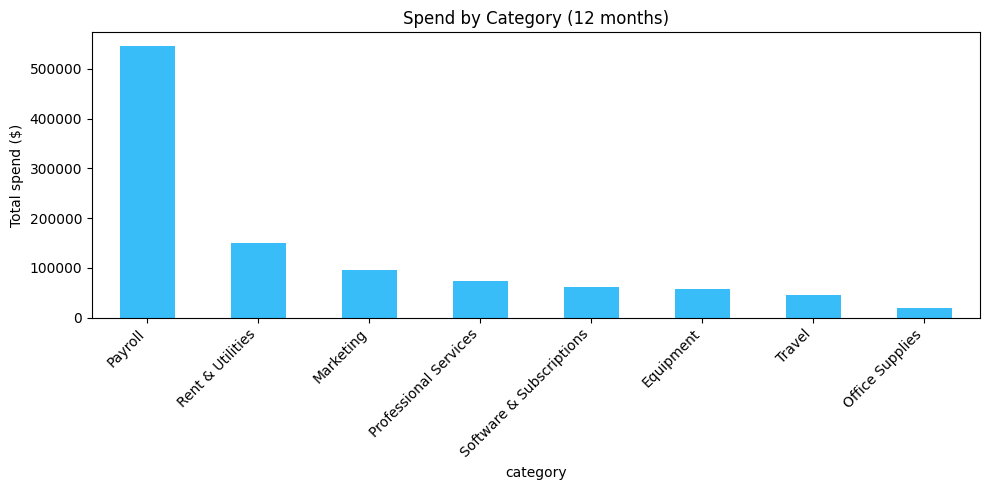

In [3]:
by_category.plot(kind="bar", color="#38bdf8", title="Spend by Category (12 months)")
plt.ylabel("Total spend ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

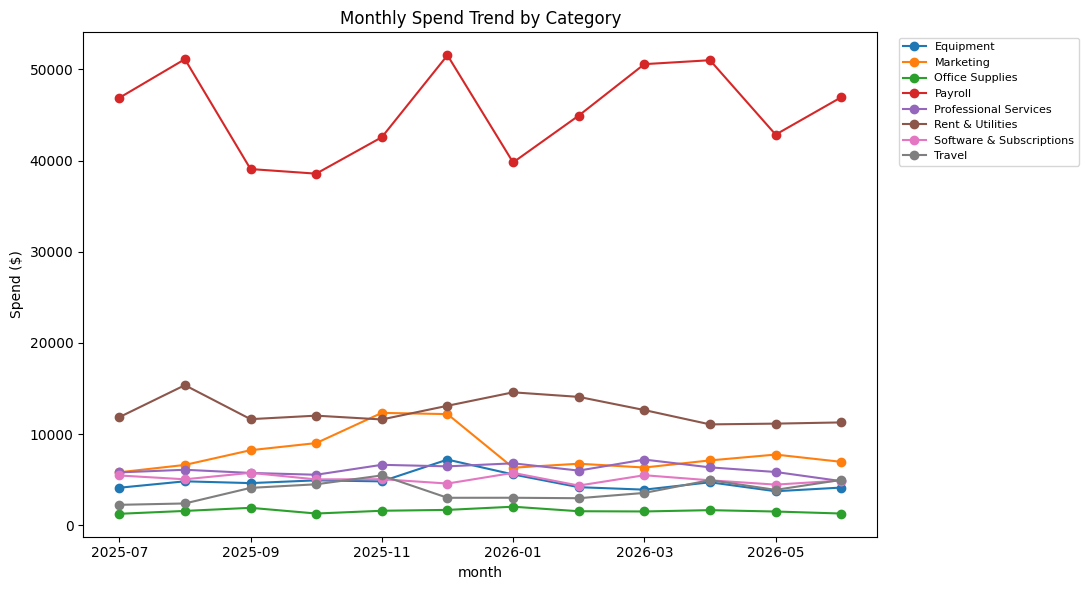

In [4]:
# Monthly trend by category (mirrors the dashboard's trend chart)
df["month"] = df["date"].dt.to_period("M").astype(str)
monthly = df.groupby(["month", "category"])["amount"].sum().unstack(fill_value=0)
monthly.plot(figsize=(11, 6), marker="o")
plt.title("Monthly Spend Trend by Category")
plt.ylabel("Spend ($)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

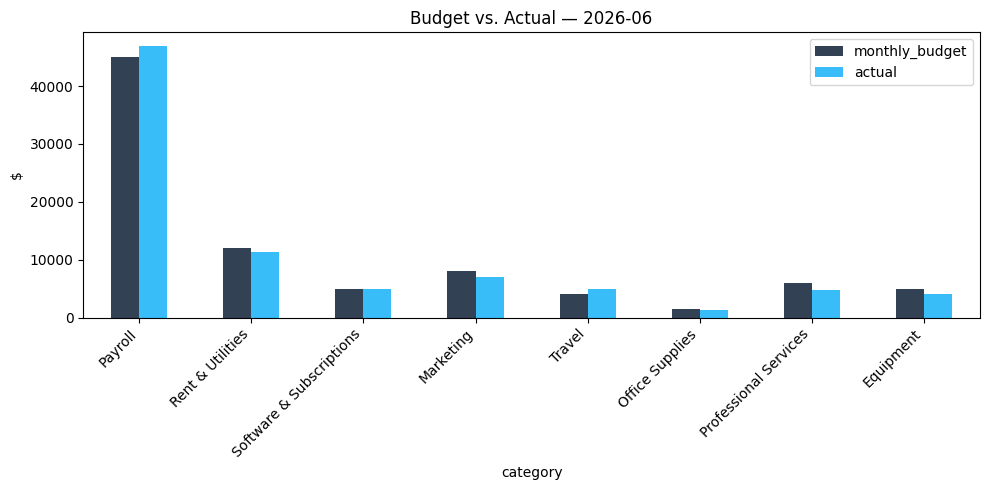

,monthly_budget,actual,over_budget
category,,,
Payroll,45000,46952.99,True
Rent & Utilities,12000,11280.25,False
Software & Subscriptions,5000,4906.63,False
Marketing,8000,6954.97,False
Travel,4000,4978.16,True
Office Supplies,1500,1285.90,False
Professional Services,6000,4839.89,False
Equipment,5000,4132.72,False


In [5]:
# Budget vs. actual for the most recent month (mirrors the dashboard's budget-status endpoint)
latest_month = df["month"].max()
actual = df[df["month"] == latest_month].groupby("category")["amount"].sum()
comparison = budgets.set_index("category").join(actual.rename("actual")).fillna(0)
comparison["over_budget"] = comparison["actual"] > comparison["monthly_budget"]

ax = comparison[["monthly_budget", "actual"]].plot(kind="bar", figsize=(10, 5),
                                                     color=["#334155", "#38bdf8"])
plt.title(f"Budget vs. Actual — {latest_month}")
plt.ylabel("$")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
comparison

In [6]:
# Top vendors by total spend
top_vendors = df.groupby("vendor")["amount"].sum().sort_values(ascending=False).head(5)
top_vendors

vendor
Gusto Payroll         322257.46
ADP                   223653.19
Comcast Business       43472.69
Skyline Properties     37242.74
Metro Electric         36688.62
Name: amount, dtype: float64

## 3. Full Source Code (Reference)

The sections below contain the complete backend and frontend implementation
exactly as used in the running application. This notebook's kernel executes
Python (used above for the data analysis); these files are Node.js/JavaScript
and HTML, so they're included here as documented source for review rather than
executed inline.

### Run it yourself

```bash
cd backend
npm install
npm run seed
npm start
```

Then open `http://localhost:4000`. Demo login: `admin@costtracker.local` / `password123`.


### 3.1 Backend — `package.json`

**`backend/package.json`**

```json
{
  "name": "cost-tracker-backend",
  "version": "1.0.0",
  "description": "Business Cost Tracker Dashboard - backend API",
  "main": "server.js",
  "type": "commonjs",
  "scripts": {
    "start": "node server.js",
    "seed": "node seed.js"
  },
  "engines": {
    "node": ">=22.5.0"
  },
  "dependencies": {
    "bcryptjs": "^2.4.3",
    "cors": "^2.8.5",
    "express": "^4.19.2",
    "jsonwebtoken": "^9.0.2"
  }
}

```

### 3.2 Backend — Database schema (`db.js`)

**`backend/db.js`**

```javascript
// Uses Node's built-in SQLite module (available in Node 22+, no native build step required).
const { DatabaseSync } = require("node:sqlite");
const path = require("path");

const db = new DatabaseSync(path.join(__dirname, "cost_tracker.db"));

db.exec(`
CREATE TABLE IF NOT EXISTS users (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name TEXT NOT NULL,
  email TEXT UNIQUE NOT NULL,
  password_hash TEXT NOT NULL,
  role TEXT NOT NULL DEFAULT 'viewer',
  created_at TEXT DEFAULT (datetime('now'))
);

CREATE TABLE IF NOT EXISTS categories (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  name TEXT UNIQUE NOT NULL,
  monthly_budget REAL NOT NULL DEFAULT 0
);

CREATE TABLE IF NOT EXISTS expenses (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  category_id INTEGER NOT NULL REFERENCES categories(id),
  vendor TEXT NOT NULL,
  amount REAL NOT NULL,
  date TEXT NOT NULL,
  description TEXT,
  created_by INTEGER REFERENCES users(id),
  created_at TEXT DEFAULT (datetime('now'))
);

CREATE INDEX IF NOT EXISTS idx_expenses_date ON expenses(date);
CREATE INDEX IF NOT EXISTS idx_expenses_category ON expenses(category_id);
`);

module.exports = db;

```

### 3.3 Backend — Auth middleware (`middleware/auth.js`)

**`backend/middleware/auth.js`**

```javascript
const jwt = require("jsonwebtoken");

const JWT_SECRET = process.env.JWT_SECRET || "capstone-dev-secret-change-me";

function requireAuth(req, res, next) {
  const header = req.headers.authorization || "";
  const token = header.startsWith("Bearer ") ? header.slice(7) : null;
  if (!token) return res.status(401).json({ error: "Missing auth token" });

  try {
    req.user = jwt.verify(token, JWT_SECRET);
    next();
  } catch (err) {
    return res.status(401).json({ error: "Invalid or expired token" });
  }
}

module.exports = { requireAuth, JWT_SECRET };

```

### 3.4 Backend — Auth routes (`routes/auth.js`)

**`backend/routes/auth.js`**

```javascript
const express = require("express");
const bcrypt = require("bcryptjs");
const jwt = require("jsonwebtoken");
const db = require("../db");
const { JWT_SECRET } = require("../middleware/auth");

const router = express.Router();

router.post("/register", (req, res) => {
  const { name, email, password } = req.body;
  if (!name || !email || !password) {
    return res.status(400).json({ error: "name, email, password are required" });
  }
  const existing = db.prepare("SELECT id FROM users WHERE email = ?").get(email);
  if (existing) return res.status(409).json({ error: "Email already registered" });

  const hash = bcrypt.hashSync(password, 10);
  const info = db
    .prepare("INSERT INTO users (name, email, password_hash, role) VALUES (?, ?, ?, 'viewer')")
    .run(name, email, hash);

  const token = jwt.sign({ id: info.lastInsertRowid, name, email, role: "viewer" }, JWT_SECRET, {
    expiresIn: "12h",
  });
  res.status(201).json({ token });
});

router.post("/login", (req, res) => {
  const { email, password } = req.body;
  const user = db.prepare("SELECT * FROM users WHERE email = ?").get(email);
  if (!user || !bcrypt.compareSync(password || "", user.password_hash)) {
    return res.status(401).json({ error: "Invalid email or password" });
  }
  const token = jwt.sign(
    { id: user.id, name: user.name, email: user.email, role: user.role },
    JWT_SECRET,
    { expiresIn: "12h" }
  );
  res.json({ token, user: { id: user.id, name: user.name, email: user.email, role: user.role } });
});

module.exports = router;

```

### 3.5 Backend — Category routes (`routes/categories.js`)

**`backend/routes/categories.js`**

```javascript
const express = require("express");
const db = require("../db");
const { requireAuth } = require("../middleware/auth");

const router = express.Router();
router.use(requireAuth);

router.get("/", (req, res) => {
  const rows = db.prepare("SELECT * FROM categories ORDER BY name").all();
  res.json(rows);
});

router.post("/", (req, res) => {
  const { name, monthly_budget } = req.body;
  if (!name) return res.status(400).json({ error: "name is required" });
  try {
    const info = db
      .prepare("INSERT INTO categories (name, monthly_budget) VALUES (?, ?)")
      .run(name, monthly_budget || 0);
    res.status(201).json({ id: info.lastInsertRowid, name, monthly_budget: monthly_budget || 0 });
  } catch (err) {
    res.status(409).json({ error: "Category already exists" });
  }
});

router.put("/:id", (req, res) => {
  const { name, monthly_budget } = req.body;
  const existing = db.prepare("SELECT * FROM categories WHERE id = ?").get(req.params.id);
  if (!existing) return res.status(404).json({ error: "Category not found" });

  db.prepare("UPDATE categories SET name = ?, monthly_budget = ? WHERE id = ?").run(
    name ?? existing.name,
    monthly_budget ?? existing.monthly_budget,
    req.params.id
  );
  res.json({ id: Number(req.params.id), name: name ?? existing.name, monthly_budget: monthly_budget ?? existing.monthly_budget });
});

router.delete("/:id", (req, res) => {
  db.prepare("DELETE FROM categories WHERE id = ?").run(req.params.id);
  res.status(204).end();
});

module.exports = router;

```

### 3.6 Backend — Expense routes (`routes/expenses.js`)

**`backend/routes/expenses.js`**

```javascript
const express = require("express");
const db = require("../db");
const { requireAuth } = require("../middleware/auth");

const router = express.Router();
router.use(requireAuth);

// GET /api/expenses?category=&vendor=&from=&to=&page=&pageSize=
router.get("/", (req, res) => {
  const { category, vendor, from, to, page = 1, pageSize = 50 } = req.query;
  const clauses = [];
  const params = {};

  if (category) {
    clauses.push("c.name = @category");
    params.category = category;
  }
  if (vendor) {
    clauses.push("e.vendor LIKE @vendor");
    params.vendor = `%${vendor}%`;
  }
  if (from) {
    clauses.push("e.date >= @from");
    params.from = from;
  }
  if (to) {
    clauses.push("e.date <= @to");
    params.to = to;
  }

  const where = clauses.length ? `WHERE ${clauses.join(" AND ")}` : "";
  const offset = (Number(page) - 1) * Number(pageSize);

  const rows = db
    .prepare(
      `SELECT e.id, e.date, c.name AS category, e.vendor, e.amount, e.description
       FROM expenses e JOIN categories c ON c.id = e.category_id
       ${where}
       ORDER BY e.date DESC
       LIMIT @limit OFFSET @offset`
    )
    .all({ ...params, limit: Number(pageSize), offset });

  const total = db
    .prepare(
      `SELECT COUNT(*) AS count FROM expenses e JOIN categories c ON c.id = e.category_id ${where}`
    )
    .get(params).count;

  res.json({ data: rows, total, page: Number(page), pageSize: Number(pageSize) });
});

router.post("/", (req, res) => {
  const { category, vendor, amount, date, description } = req.body;
  if (!category || !vendor || !amount || !date) {
    return res.status(400).json({ error: "category, vendor, amount, date are required" });
  }
  const cat = db.prepare("SELECT id FROM categories WHERE name = ?").get(category);
  if (!cat) return res.status(400).json({ error: "Unknown category" });

  const info = db
    .prepare(
      "INSERT INTO expenses (category_id, vendor, amount, date, description, created_by) VALUES (?, ?, ?, ?, ?, ?)"
    )
    .run(cat.id, vendor, amount, date, description || null, req.user.id);

  res.status(201).json({ id: info.lastInsertRowid, category, vendor, amount, date, description });
});

router.put("/:id", (req, res) => {
  const existing = db.prepare("SELECT * FROM expenses WHERE id = ?").get(req.params.id);
  if (!existing) return res.status(404).json({ error: "Expense not found" });

  const { category, vendor, amount, date, description } = req.body;
  let categoryId = existing.category_id;
  if (category) {
    const cat = db.prepare("SELECT id FROM categories WHERE name = ?").get(category);
    if (!cat) return res.status(400).json({ error: "Unknown category" });
    categoryId = cat.id;
  }

  db.prepare(
    "UPDATE expenses SET category_id = ?, vendor = ?, amount = ?, date = ?, description = ? WHERE id = ?"
  ).run(
    categoryId,
    vendor ?? existing.vendor,
    amount ?? existing.amount,
    date ?? existing.date,
    description ?? existing.description,
    req.params.id
  );

  res.json({ id: Number(req.params.id), updated: true });
});

router.delete("/:id", (req, res) => {
  db.prepare("DELETE FROM expenses WHERE id = ?").run(req.params.id);
  res.status(204).end();
});

module.exports = router;

```

### 3.7 Backend — Analytics routes (`routes/analytics.js`)

**`backend/routes/analytics.js`**

```javascript
const express = require("express");
const db = require("../db");
const { requireAuth } = require("../middleware/auth");

const router = express.Router();
router.use(requireAuth);

// Total spend + spend by category (all time or optional ?from=&to=)
router.get("/summary", (req, res) => {
  const { from, to } = req.query;
  const clauses = [];
  const params = {};
  if (from) { clauses.push("e.date >= @from"); params.from = from; }
  if (to) { clauses.push("e.date <= @to"); params.to = to; }
  const where = clauses.length ? `WHERE ${clauses.join(" AND ")}` : "";

  const totalSpend = db
    .prepare(`SELECT COALESCE(SUM(e.amount),0) AS total FROM expenses e ${where}`)
    .get(params).total;

  const byCategory = db
    .prepare(
      `SELECT c.name AS category, COALESCE(SUM(e.amount),0) AS total
       FROM categories c LEFT JOIN expenses e ON e.category_id = c.id ${where.replace("WHERE", where ? "AND" : "")}
       GROUP BY c.id ORDER BY total DESC`
    )
    .all(params);

  const topVendors = db
    .prepare(
      `SELECT e.vendor, COALESCE(SUM(e.amount),0) AS total
       FROM expenses e ${where}
       GROUP BY e.vendor ORDER BY total DESC LIMIT 5`
    )
    .all(params);

  res.json({ totalSpend, byCategory, topVendors });
});

// Monthly trend: total spend per month, plus per-category breakdown
router.get("/monthly-trend", (req, res) => {
  const rows = db
    .prepare(
      `SELECT strftime('%Y-%m', e.date) AS month, c.name AS category, SUM(e.amount) AS total
       FROM expenses e JOIN categories c ON c.id = e.category_id
       GROUP BY month, c.name
       ORDER BY month ASC`
    )
    .all();
  res.json(rows);
});

// Budget vs actual for the most recent month present in the data
router.get("/budget-status", (req, res) => {
  const latestMonth = db
    .prepare(`SELECT MAX(strftime('%Y-%m', date)) AS m FROM expenses`)
    .get().m;

  const rows = db
    .prepare(
      `SELECT c.name AS category, c.monthly_budget AS budget,
              COALESCE(SUM(CASE WHEN strftime('%Y-%m', e.date) = ? THEN e.amount END), 0) AS actual
       FROM categories c LEFT JOIN expenses e ON e.category_id = c.id
       GROUP BY c.id`
    )
    .all(latestMonth);

  res.json({ month: latestMonth, categories: rows });
});

module.exports = router;

```

### 3.8 Backend — Server entrypoint (`server.js`)

**`backend/server.js`**

```javascript
const express = require("express");
const cors = require("cors");
const path = require("path");

const authRoutes = require("./routes/auth");
const categoryRoutes = require("./routes/categories");
const expenseRoutes = require("./routes/expenses");
const analyticsRoutes = require("./routes/analytics");

const app = express();
const PORT = process.env.PORT || 4000;

app.use(cors());
app.use(express.json());

app.use("/api/auth", authRoutes);
app.use("/api/categories", categoryRoutes);
app.use("/api/expenses", expenseRoutes);
app.use("/api/analytics", analyticsRoutes);

// Serve the frontend as static files
app.use(express.static(path.join(__dirname, "..", "frontend", "public")));

app.get("/health", (req, res) => res.json({ status: "ok" }));

app.listen(PORT, () => {
  console.log(`Cost Tracker API running on http://localhost:${PORT}`);
});

```

### 3.9 Backend — Database seed script (`seed.js`)

**`backend/seed.js`**

```javascript
// Loads categories.csv and expenses.csv (synthetic data) into the SQLite database.
const fs = require("fs");
const path = require("path");
const bcrypt = require("bcryptjs");
const db = require("./db");

function parseCsv(filePath) {
  const text = fs.readFileSync(filePath, "utf8").trim();
  const lines = text.split(/\r\n|\r|\n/).filter((l) => l.length > 0);
  const [headerLine, ...rows] = lines;
  const headers = headerLine.split(",").map((h) => h.trim());
  return rows.map((line) => {
    const values = line.split(",");
    const row = {};
    headers.forEach((h, i) => (row[h] = values[i] !== undefined ? values[i].trim() : ""));
    return row;
  });
}

function seed() {
  const categoriesPath = path.join(__dirname, "data", "categories.csv");
  const expensesPath = path.join(__dirname, "data", "expenses.csv");

  const categories = parseCsv(categoriesPath);
  const expenses = parseCsv(expensesPath);

  const insertCategory = db.prepare(
    "INSERT OR IGNORE INTO categories (name, monthly_budget) VALUES (?, ?)"
  );
  const getCategoryId = db.prepare("SELECT id FROM categories WHERE name = ?");
  const insertExpense = db.prepare(
    "INSERT INTO expenses (category_id, vendor, amount, date, description) VALUES (?, ?, ?, ?, ?)"
  );
  const insertUser = db.prepare(
    "INSERT OR IGNORE INTO users (name, email, password_hash, role) VALUES (?, ?, ?, ?)"
  );

  db.exec("BEGIN");
  try {
    db.exec("DELETE FROM expenses; DELETE FROM categories; DELETE FROM users;");

    categories.forEach((c) => {
      insertCategory.run(c.category, parseFloat(c.monthly_budget));
    });

    let insertedCount = 0;
    expenses.forEach((e) => {
      const cat = getCategoryId.get(e.category);
      if (!cat) return;
      insertExpense.run(
        cat.id,
        e.vendor || "",
        parseFloat(e.amount),
        e.date,
        e.description || ""
      );
      insertedCount++;
    });

    const hash = bcrypt.hashSync("password123", 10);
    insertUser.run("Demo Admin", "admin@costtracker.local", hash, "admin");

    db.exec("COMMIT");
    console.log(`Seeded ${categories.length} categories and ${insertedCount} expenses.`);
  } catch (err) {
    db.exec("ROLLBACK");
    throw err;
  }

  console.log("Demo login -> email: admin@costtracker.local  password: password123");
}

seed();

```

### 3.10 Synthetic data generator (`data/generate_dataset.py`)

**`backend/data/generate_dataset.py`**

```python
"""
Generates synthetic business expense data for the Cost Tracker Dashboard capstone.
Produces: categories.csv, expenses.csv (12 months of realistic, seasonally-varied spend).
"""
import csv
import random
from datetime import date, timedelta

random.seed(42)

CATEGORIES = [
    ("Payroll", 45000),
    ("Rent & Utilities", 12000),
    ("Software & Subscriptions", 5000),
    ("Marketing", 8000),
    ("Travel", 4000),
    ("Office Supplies", 1500),
    ("Professional Services", 6000),
    ("Equipment", 5000),
]

VENDORS = {
    "Payroll": ["Gusto Payroll", "ADP"],
    "Rent & Utilities": ["Skyline Properties", "Metro Electric", "CityWater Co", "Comcast Business"],
    "Software & Subscriptions": ["AWS", "Slack", "Salesforce", "Adobe", "Zoom", "GitHub"],
    "Marketing": ["Meta Ads", "Google Ads", "Mailchimp", "LinkedIn Ads", "Canva"],
    "Travel": ["Delta Airlines", "Marriott", "Uber for Business", "United Airlines"],
    "Office Supplies": ["Staples", "Amazon Business", "Office Depot"],
    "Professional Services": ["Deloitte Consulting", "Local Law Partners", "TaxPro CPA"],
    "Equipment": ["Dell", "Apple Business", "Herman Miller"],
}

# seasonal multipliers by month (1=Jan ... 12=Dec) per category
SEASONALITY = {
    "Payroll": [1.0]*11 + [1.15],  # year-end bonus bump
    "Rent & Utilities": [1.15, 1.1, 1.0, 0.95, 0.9, 1.05, 1.15, 1.15, 0.95, 0.9, 1.0, 1.1],
    "Software & Subscriptions": [1.0]*12,
    "Marketing": [0.8, 0.8, 0.9, 1.0, 1.0, 0.9, 0.8, 0.9, 1.1, 1.2, 1.4, 1.5],  # Q4 push
    "Travel": [0.7, 0.8, 1.0, 1.1, 1.0, 1.1, 0.6, 0.6, 1.1, 1.2, 1.3, 0.8],
    "Office Supplies": [1.2, 0.9, 0.9, 1.0, 1.0, 0.9, 0.9, 1.1, 1.2, 1.0, 1.0, 1.1],
    "Professional Services": [1.3, 1.0, 1.4, 1.0, 0.9, 0.9, 0.9, 0.9, 1.0, 1.0, 1.0, 1.2],
    "Equipment": [1.1, 0.8, 0.8, 0.9, 0.8, 0.8, 0.8, 1.0, 1.0, 0.9, 0.9, 1.3],
}

START = date(2025, 7, 1)
MONTHS = 12

def month_range(start, n):
    y, m = start.year, start.month
    out = []
    for i in range(n):
        out.append((y, m))
        m += 1
        if m > 12:
            m = 1
            y += 1
    return out

def random_date_in_month(y, m):
    if m == 12:
        next_m = date(y + 1, 1, 1)
    else:
        next_m = date(y, m + 1, 1)
    days_in_month = (next_m - date(y, m, 1)).days
    return date(y, m, random.randint(1, days_in_month))

rows = []
expense_id = 1
categories_out = []

for cat_name, monthly_budget in CATEGORIES:
    categories_out.append({"category": cat_name, "monthly_budget": monthly_budget})

for (y, m) in month_range(START, MONTHS):
    month_idx = (m - 1)
    for cat_name, monthly_budget in CATEGORIES:
        mult = SEASONALITY[cat_name][month_idx]
        target_spend = monthly_budget * mult * random.uniform(0.85, 1.15)
        # split target spend into 3-8 line-item transactions
        n_txns = random.randint(3, 8)
        weights = [random.random() for _ in range(n_txns)]
        wsum = sum(weights)
        for w in weights:
            amount = round(target_spend * (w / wsum), 2)
            vendor = random.choice(VENDORS[cat_name])
            rows.append({
                "id": expense_id,
                "date": random_date_in_month(y, m).isoformat(),
                "category": cat_name,
                "vendor": vendor,
                "amount": amount,
                "description": f"{cat_name} expense - {vendor}",
            })
            expense_id += 1

rows.sort(key=lambda r: r["date"])

with open("expenses.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "date", "category", "vendor", "amount", "description"])
    writer.writeheader()
    writer.writerows(rows)

with open("categories.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["category", "monthly_budget"])
    writer.writeheader()
    writer.writerows(categories_out)

print(f"Generated {len(rows)} expense rows across {len(CATEGORIES)} categories over {MONTHS} months.")

```

### 3.11 Frontend — Dashboard SPA (`frontend/public/index.html`)

**`frontend/public/index.html`**

```html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8" />
<meta name="viewport" content="width=device-width, initial-scale=1.0" />
<title>Business Cost Tracker Dashboard</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<style>
  :root {
    --bg: #0f172a;
    --panel: #1e293b;
    --panel-light: #273449;
    --accent: #38bdf8;
    --accent2: #34d399;
    --danger: #f87171;
    --text: #e2e8f0;
    --text-dim: #94a3b8;
    --border: #334155;
  }
  * { box-sizing: border-box; }
  body {
    margin: 0;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: var(--bg);
    color: var(--text);
  }
  #login-view {
    display: flex;
    align-items: center;
    justify-content: center;
    height: 100vh;
  }
  .login-card {
    background: var(--panel);
    padding: 2.5rem;
    border-radius: 12px;
    width: 340px;
    border: 1px solid var(--border);
  }
  .login-card h1 { font-size: 1.3rem; margin-bottom: 1.5rem; }
  .login-card input {
    width: 100%;
    padding: 0.6rem 0.8rem;
    margin-bottom: 0.9rem;
    border-radius: 6px;
    border: 1px solid var(--border);
    background: var(--panel-light);
    color: var(--text);
  }
  .login-card button, .btn {
    width: 100%;
    padding: 0.65rem;
    background: var(--accent);
    color: #0f172a;
    font-weight: 600;
    border: none;
    border-radius: 6px;
    cursor: pointer;
  }
  .login-card button:hover, .btn:hover { opacity: 0.9; }
  .hint { color: var(--text-dim); font-size: 0.8rem; margin-top: 1rem; }
  .error-msg { color: var(--danger); font-size: 0.85rem; margin-bottom: 0.5rem; min-height: 1em; }

  #app-view { display: none; padding: 1.5rem 2rem; max-width: 1300px; margin: 0 auto; }
  header.topbar {
    display: flex; justify-content: space-between; align-items: center;
    margin-bottom: 1.5rem;
  }
  header.topbar h1 { font-size: 1.4rem; margin: 0; }
  #logout-btn {
    background: transparent; border: 1px solid var(--border); color: var(--text-dim);
    padding: 0.4rem 0.9rem; border-radius: 6px; cursor: pointer;
  }

  .kpi-row { display: flex; gap: 1rem; margin-bottom: 1.5rem; flex-wrap: wrap; }
  .kpi-card {
    background: var(--panel); border: 1px solid var(--border); border-radius: 10px;
    padding: 1.1rem 1.4rem; flex: 1; min-width: 180px;
  }
  .kpi-card .label { color: var(--text-dim); font-size: 0.8rem; text-transform: uppercase; letter-spacing: 0.04em; }
  .kpi-card .value { font-size: 1.6rem; font-weight: 700; margin-top: 0.3rem; }

  .grid-2 { display: grid; grid-template-columns: 1.3fr 1fr; gap: 1.2rem; margin-bottom: 1.5rem; }
  .panel { background: var(--panel); border: 1px solid var(--border); border-radius: 10px; padding: 1.2rem; }
  .panel h2 { font-size: 1rem; margin: 0 0 0.9rem 0; color: var(--text-dim); font-weight: 600; }
  .chart-wrap { position: relative; height: 260px; }

  table { width: 100%; border-collapse: collapse; font-size: 0.87rem; }
  th, td { text-align: left; padding: 0.5rem 0.6rem; border-bottom: 1px solid var(--border); }
  th { color: var(--text-dim); font-weight: 600; font-size: 0.78rem; text-transform: uppercase; }
  tr:hover td { background: var(--panel-light); }

  .filters { display: flex; gap: 0.6rem; margin-bottom: 1rem; flex-wrap: wrap; }
  .filters select, .filters input { padding: 0.4rem 0.6rem; border-radius: 6px; border: 1px solid var(--border); background: var(--panel-light); color: var(--text); font-size: 0.85rem; }

  .add-form { display: flex; gap: 0.6rem; margin-bottom: 1rem; flex-wrap: wrap; align-items: center; }
  .add-form input, .add-form select { padding: 0.4rem 0.6rem; border-radius: 6px; border: 1px solid var(--border); background: var(--panel-light); color: var(--text); font-size: 0.85rem; }
  .add-form button { padding: 0.45rem 1rem; background: var(--accent2); border: none; border-radius: 6px; color: #0f172a; font-weight: 600; cursor: pointer; }

  .pagination { display: flex; gap: 0.5rem; margin-top: 0.8rem; align-items: center; }
  .pagination button { background: var(--panel-light); border: 1px solid var(--border); color: var(--text); border-radius: 6px; padding: 0.3rem 0.7rem; cursor: pointer; }
  .pagination button:disabled { opacity: 0.4; cursor: default; }

  .over-budget { color: var(--danger); font-weight: 600; }
  .under-budget { color: var(--accent2); }
  .del-btn { background: transparent; border: none; color: var(--danger); cursor: pointer; font-size: 0.9rem; }
</style>
</head>
<body>

<div id="login-view">
  <div class="login-card">
    <h1>Cost Tracker Dashboard</h1>
    <div class="error-msg" id="login-error"></div>
    <input id="login-email" type="email" placeholder="Email" value="admin@costtracker.local" />
    <input id="login-password" type="password" placeholder="Password" value="password123" />
    <button onclick="login()">Sign In</button>
    <div class="hint">Demo login: admin@costtracker.local / password123</div>
  </div>
</div>

<div id="app-view">
  <header class="topbar">
    <h1>Business Cost Tracker</h1>
    <button id="logout-btn" onclick="logout()">Log out</button>
  </header>

  <div class="kpi-row" id="kpi-row"></div>

  <div class="grid-2">
    <div class="panel">
      <h2>Monthly Spend Trend</h2>
      <div class="chart-wrap"><canvas id="trend-chart"></canvas></div>
    </div>
    <div class="panel">
      <h2>Spend by Category</h2>
      <div class="chart-wrap"><canvas id="category-chart"></canvas></div>
    </div>
  </div>

  <div class="grid-2">
    <div class="panel">
      <h2>Budget vs Actual (Current Month)</h2>
      <div class="chart-wrap"><canvas id="budget-chart"></canvas></div>
    </div>
    <div class="panel">
      <h2>Top Vendors</h2>
      <table id="vendor-table">
        <thead><tr><th>Vendor</th><th>Total Spend</th></tr></thead>
        <tbody></tbody>
      </table>
    </div>
  </div>

  <div class="panel" style="margin-bottom:1.5rem;">
    <h2>Add Expense</h2>
    <div class="add-form">
      <select id="new-category"></select>
      <input id="new-vendor" placeholder="Vendor" />
      <input id="new-amount" type="number" step="0.01" placeholder="Amount" />
      <input id="new-date" type="date" />
      <input id="new-description" placeholder="Description" style="flex:1; min-width:150px;" />
      <button onclick="addExpense()">Add</button>
    </div>
  </div>

  <div class="panel">
    <h2>Expenses</h2>
    <div class="filters">
      <select id="filter-category"><option value="">All categories</option></select>
      <input id="filter-vendor" placeholder="Search vendor..." oninput="debouncedLoadExpenses()" />
      <input id="filter-from" type="date" onchange="loadExpenses(1)" />
      <input id="filter-to" type="date" onchange="loadExpenses(1)" />
    </div>
    <table>
      <thead><tr><th>Date</th><th>Category</th><th>Vendor</th><th>Amount</th><th>Description</th><th></th></tr></thead>
      <tbody id="expenses-tbody"></tbody>
    </table>
    <div class="pagination">
      <button id="prev-page" onclick="changePage(-1)">Prev</button>
      <span id="page-label"></span>
      <button id="next-page" onclick="changePage(1)">Next</button>
    </div>
  </div>
</div>

<script>
const API = "/api";
let token = null;
let categories = [];
let currentPage = 1;
let pageSize = 8;
let totalExpenses = 0;
let charts = {};

function fmtMoney(n) {
  return "$" + Number(n).toLocaleString(undefined, { minimumFractionDigits: 2, maximumFractionDigits: 2 });
}

async function api(path, options = {}) {
  const res = await fetch(API + path, {
    ...options,
    headers: {
      "Content-Type": "application/json",
      ...(token ? { Authorization: "Bearer " + token } : {}),
      ...(options.headers || {}),
    },
  });
  if (!res.ok) {
    const body = await res.json().catch(() => ({}));
    throw new Error(body.error || ("Request failed: " + res.status));
  }
  if (res.status === 204) return null;
  return res.json();
}

async function login() {
  const email = document.getElementById("login-email").value;
  const password = document.getElementById("login-password").value;
  const errEl = document.getElementById("login-error");
  errEl.textContent = "";
  try {
    const data = await api("/auth/login", { method: "POST", body: JSON.stringify({ email, password }) });
    token = data.token;
    sessionStorage_set(token);
    showApp();
  } catch (err) {
    errEl.textContent = err.message;
  }
}

// In-memory only (no browser storage APIs used) -- token lives for the page session.
function sessionStorage_set(t) { /* intentionally in-memory; kept as a named no-op for clarity */ }

function logout() {
  token = null;
  document.getElementById("app-view").style.display = "none";
  document.getElementById("login-view").style.display = "flex";
}

async function showApp() {
  document.getElementById("login-view").style.display = "none";
  document.getElementById("app-view").style.display = "block";
  await loadCategories();
  await Promise.all([loadSummary(), loadTrend(), loadBudgetStatus(), loadExpenses(1)]);
}

async function loadCategories() {
  categories = await api("/categories");
  const newCatSel = document.getElementById("new-category");
  const filterCatSel = document.getElementById("filter-category");
  newCatSel.innerHTML = categories.map((c) => `<option value="${c.name}">${c.name}</option>`).join("");
  filterCatSel.innerHTML = `<option value="">All categories</option>` + categories.map((c) => `<option value="${c.name}">${c.name}</option>`).join("");
}

async function loadSummary() {
  const data = await api("/analytics/summary");
  const kpiRow = document.getElementById("kpi-row");
  const topCategory = data.byCategory[0];
  kpiRow.innerHTML = `
    <div class="kpi-card"><div class="label">Total Spend</div><div class="value">${fmtMoney(data.totalSpend)}</div></div>
    <div class="kpi-card"><div class="label">Categories Tracked</div><div class="value">${data.byCategory.length}</div></div>
    <div class="kpi-card"><div class="label">Top Category</div><div class="value" style="font-size:1.1rem;">${topCategory ? topCategory.category : "-"}</div></div>
    <div class="kpi-card"><div class="label">Top Vendor</div><div class="value" style="font-size:1.1rem;">${data.topVendors[0] ? data.topVendors[0].vendor : "-"}</div></div>
  `;

  const vendorTbody = document.querySelector("#vendor-table tbody");
  vendorTbody.innerHTML = data.topVendors.map((v) => `<tr><td>${v.vendor}</td><td>${fmtMoney(v.total)}</td></tr>`).join("");

  const ctx = document.getElementById("category-chart");
  if (charts.category) charts.category.destroy();
  charts.category = new Chart(ctx, {
    type: "doughnut",
    data: {
      labels: data.byCategory.map((c) => c.category),
      datasets: [{
        data: data.byCategory.map((c) => c.total),
        backgroundColor: ["#38bdf8","#34d399","#fbbf24","#f87171","#a78bfa","#fb923c","#22d3ee","#f472b6"],
        borderWidth: 0,
      }],
    },
    options: { plugins: { legend: { position: "right", labels: { color: "#e2e8f0", boxWidth: 12, font: { size: 11 } } } } },
  });
}

async function loadTrend() {
  const rows = await api("/analytics/monthly-trend");
  const months = [...new Set(rows.map((r) => r.month))].sort();
  const cats = [...new Set(rows.map((r) => r.category))];
  const palette = ["#38bdf8","#34d399","#fbbf24","#f87171","#a78bfa","#fb923c","#22d3ee","#f472b6"];

  const datasets = cats.map((cat, i) => ({
    label: cat,
    data: months.map((m) => {
      const match = rows.find((r) => r.month === m && r.category === cat);
      return match ? match.total : 0;
    }),
    borderColor: palette[i % palette.length],
    backgroundColor: palette[i % palette.length],
    tension: 0.3,
    fill: false,
  }));

  const ctx = document.getElementById("trend-chart");
  if (charts.trend) charts.trend.destroy();
  charts.trend = new Chart(ctx, {
    type: "line",
    data: { labels: months, datasets },
    options: {
      plugins: { legend: { labels: { color: "#e2e8f0", boxWidth: 10, font: { size: 10 } } } },
      scales: {
        x: { ticks: { color: "#94a3b8" }, grid: { color: "#334155" } },
        y: { ticks: { color: "#94a3b8" }, grid: { color: "#334155" } },
      },
    },
  });
}

async function loadBudgetStatus() {
  const data = await api("/analytics/budget-status");
  const ctx = document.getElementById("budget-chart");
  if (charts.budget) charts.budget.destroy();
  charts.budget = new Chart(ctx, {
    type: "bar",
    data: {
      labels: data.categories.map((c) => c.category),
      datasets: [
        { label: "Budget", data: data.categories.map((c) => c.budget), backgroundColor: "#334155" },
        { label: "Actual", data: data.categories.map((c) => c.actual), backgroundColor: "#38bdf8" },
      ],
    },
    options: {
      plugins: { legend: { labels: { color: "#e2e8f0" } } },
      scales: {
        x: { ticks: { color: "#94a3b8", font: { size: 9 } }, grid: { display: false } },
        y: { ticks: { color: "#94a3b8" }, grid: { color: "#334155" } },
      },
    },
  });
}

let debounceTimer;
function debouncedLoadExpenses() {
  clearTimeout(debounceTimer);
  debounceTimer = setTimeout(() => loadExpenses(1), 350);
}

async function loadExpenses(page) {
  currentPage = page || currentPage;
  const category = document.getElementById("filter-category").value;
  const vendor = document.getElementById("filter-vendor").value;
  const from = document.getElementById("filter-from").value;
  const to = document.getElementById("filter-to").value;

  const params = new URLSearchParams({ page: currentPage, pageSize });
  if (category) params.set("category", category);
  if (vendor) params.set("vendor", vendor);
  if (from) params.set("from", from);
  if (to) params.set("to", to);

  const data = await api("/expenses?" + params.toString());
  totalExpenses = data.total;

  const tbody = document.getElementById("expenses-tbody");
  tbody.innerHTML = data.data.map((e) => `
    <tr>
      <td>${e.date}</td>
      <td>${e.category}</td>
      <td>${e.vendor}</td>
      <td>${fmtMoney(e.amount)}</td>
      <td>${e.description || ""}</td>
      <td><button class="del-btn" onclick="deleteExpense(${e.id})">Delete</button></td>
    </tr>
  `).join("") || `<tr><td colspan="6" style="color:#94a3b8;">No expenses found.</td></tr>`;

  const totalPages = Math.max(1, Math.ceil(totalExpenses / pageSize));
  document.getElementById("page-label").textContent = `Page ${currentPage} of ${totalPages}`;
  document.getElementById("prev-page").disabled = currentPage <= 1;
  document.getElementById("next-page").disabled = currentPage >= totalPages;
}

function changePage(delta) {
  const totalPages = Math.max(1, Math.ceil(totalExpenses / pageSize));
  const next = Math.min(Math.max(1, currentPage + delta), totalPages);
  loadExpenses(next);
}

async function addExpense() {
  const category = document.getElementById("new-category").value;
  const vendor = document.getElementById("new-vendor").value;
  const amount = parseFloat(document.getElementById("new-amount").value);
  const date = document.getElementById("new-date").value;
  const description = document.getElementById("new-description").value;

  if (!category || !vendor || !amount || !date) {
    alert("Please fill in category, vendor, amount, and date.");
    return;
  }

  await api("/expenses", { method: "POST", body: JSON.stringify({ category, vendor, amount, date, description }) });
  document.getElementById("new-vendor").value = "";
  document.getElementById("new-amount").value = "";
  document.getElementById("new-date").value = "";
  document.getElementById("new-description").value = "";

  await Promise.all([loadSummary(), loadTrend(), loadBudgetStatus(), loadExpenses(1)]);
}

async function deleteExpense(id) {
  if (!confirm("Delete this expense?")) return;
  await api("/expenses/" + id, { method: "DELETE" });
  await Promise.all([loadSummary(), loadTrend(), loadBudgetStatus(), loadExpenses(currentPage)]);
}
</script>
</body>
</html>

```

## 4. Summary

This project demonstrates a complete full-stack application: authenticated REST
API, relational data model, synthetic-but-realistic dataset generation, and a
dashboard UI — all runnable locally with no external services or paid APIs.
See `README.md` and `HACKATHON_WRITEUP.md` in the project folder for the full
write-up (inspiration, challenges, and what's next).
